In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
### Loading Dataset
data=pd.read_csv("C:\\Users\\srush\\OneDrive\\Desktop\\AIML Internship\\AIML-Internship\\Day31_Unsupervised Learning\\Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
## checking null values
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
## Selecting Relevant features for Clustering
x = data[["Annual Income (k$)","Spending Score (1-100)"]]

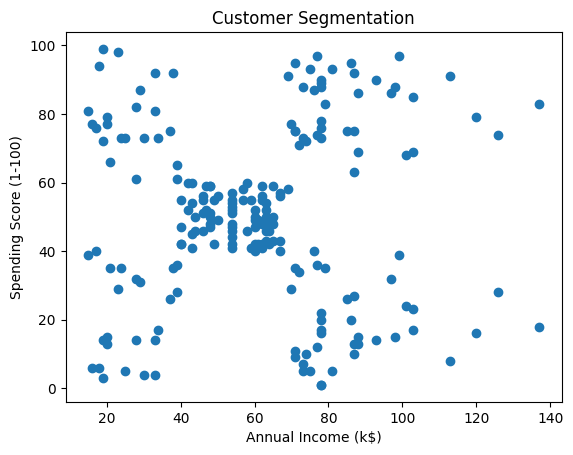

In [5]:
## Visuvalizing the Data
plt.scatter(x["Annual Income (k$)"],x["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")
plt.show()

Text(0, 0.5, 'wcss scores')

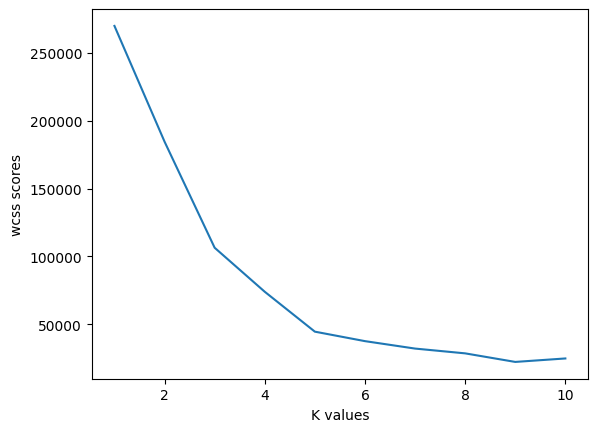

In [ ]:
## Finding a K value using Elbow Method

wcss = [] # Within Cluster Sum of Squares ,Create an empty list to store the wcss score
for k in range (1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,11),wcss)
plt.xlabel("K values")
plt.ylabel("wcss scores")


In [17]:
for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)

    print("K =",k," Silhouette Score =",score)

K = 2  Silhouette Score = 0.39564531743995546
K = 3  Silhouette Score = 0.46761358158775435
K = 4  Silhouette Score = 0.4937945814354117
K = 5  Silhouette Score = 0.553931997444648
K = 6  Silhouette Score = 0.5128405328004378
K = 7  Silhouette Score = 0.5017174409749505
K = 8  Silhouette Score = 0.4962769338093321
K = 9  Silhouette Score = 0.45587414130065596
K = 10  Silhouette Score = 0.4426214845978157


In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(x)
labels = kmeans.predict(x)
labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [15]:
data["labels"] = labels
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),labels
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


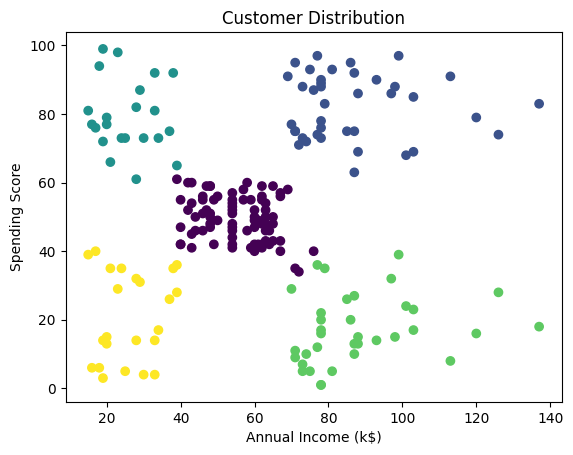

In [16]:
plt.scatter(x['Annual Income (k$)'], x['Spending Score (1-100)'],c=labels)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()